In [1]:
import matplotlib.colors as mcolors
import matplotlib.animation as ma
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from itertools import product
import pandas as pd
import numpy as np
import numba as nb
import imageio
import os
import shutil

randomSeed = 100

%matplotlib inline
%config InlineBackend.figure_format = "retina"

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "new", plt.cm.hsv(np.linspace(0, 1, 256)) * 0.85, N=256
)
# colors = ["#95D3A2", "#FFFFBF", "#F79051", ]
colors = ["#5657A4", "#95D3A2", "#FFFFBF", "#F79051", "#A30644"]
cmap = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors)
cmap_r = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors[::-1])

@nb.njit
def colors_idx(phaseTheta):
    return np.floor(256 - phaseTheta / (2 * np.pi) * 256).astype(np.int32)

import seaborn as sns

sns.set_theme(
    style="ticks", 
    font_scale=1.1, rc={
    'figure.figsize': (6, 5),
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.5,
    "lines.linewidth": 1.5,
    'text.color': '#000000',
    'figure.titleweight': "bold",
    'xtick.color': '#000000',
    'ytick.color': '#000000'
})

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['animation.ffmpeg_path'] = "/opt/conda/bin/ffmpeg"

from main import *
from multiprocessing import Pool
import pandas as pd

SAVE_PATH = r"F:\MS_ExperimentData\general"
# SAVE_PATH = r"D:\MS_ExperimentData\general"

In [16]:
class CLV(PatternFormation):
    def __init__(self, k1: float, k2: float, k3: float, k4: float,
                 boundaryLength: float = 10, speedV: float = 3, 
                 diameter: float = 0.1, repelPower: float = 1,
                 chemoAlpha1: float = 1, chemoAlpha2: float = 1,
                 diffusionRateD1: float = 1, diffusionRateD2: float = 1,
                 cellNumInLine: int = 50, agentsNum: int=1000, dt: float=0.01,
                 tqdm: bool = False, savePath: str = None, shotsnaps: int = 10,
                 randomSeed: int = 10, overWrite: bool = False) -> None:
        
        np.random.seed(randomSeed)

        self.randomSeed = randomSeed
        self.cellNumInLine = cellNumInLine
        self.cPosition = np.array(list(product(np.linspace(0, boundaryLength, cellNumInLine), repeat=2)))
        self.dx = boundaryLength / (cellNumInLine - 1)
        self.boundaryLength = boundaryLength
        self.halfBoundaryLength = boundaryLength / 2
        self.agentsNum = agentsNum
        self.k1 = k1
        self.k2 = k2
        self.k3 = k3
        self.k4 = k4
        self.diffusionRateD1 = diffusionRateD1
        self.diffusionRateD2 = diffusionRateD2
        self.dt = dt
        self.speedV = speedV
        self.tqdm = tqdm
        self.savePath = savePath
        self.shotsnaps = shotsnaps
        self.counts = 0
        self.overWrite = overWrite
        self.halfAgentsNum = agentsNum // 2
        self.chemoAlpha1Mat = chemoAlpha1 * np.concatenate([
            np.ones(self.halfAgentsNum), np.zeros(self.halfAgentsNum)
        ]).reshape(-1, 1)
        self.chemoAlpha2Mat = chemoAlpha2 * np.concatenate([
            np.zeros(self.halfAgentsNum), np.ones(self.halfAgentsNum)
        ]).reshape(-1, 1)
        self.chemoAlpha1 = chemoAlpha1
        self.chemoAlpha2 = chemoAlpha2
        self.diameter = diameter
        self.repelPower = repelPower

        self.positionX = np.random.random((agentsNum, 2)) * boundaryLength
        # self.positionX = np.concatenate([
        #     np.random.random((self.halfAgentsNum, 2)) * boundaryLength / 2,
        #     np.random.random((self.halfAgentsNum, 2)) * boundaryLength / 2 + boundaryLength / 2
        # ])
        self.phaseTheta = np.random.random(agentsNum) * 2 * np.pi - np.pi
        self.c1 = np.random.rand(cellNumInLine, cellNumInLine)
        self.c2 = np.random.rand(cellNumInLine, cellNumInLine)

        self.temp = dict()
        # The order of variable definitions has a dependency relationship
        self.temp["ocsiIdx"] = (self.positionX / self.dx).round().astype(int)
        self.temp["direction"] = self.localGradient
        self.temp["dotC1"] = self.dotC1
        self.temp["dotC2"] = self.dotC2

    def plot(self, ax: plt.Axes = None):
        if ax is None:
            _, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(
            self.positionX[:self.agentsNum // 2, 0], self.positionX[:self.agentsNum // 2, 1],
            color="#F8B08E", s=100 * self.diameter / 0.1 * (2.5 / self.boundaryLength) # edgecolors="black"
        )
        ax.scatter(
            self.positionX[self.agentsNum // 2:, 0], self.positionX[self.agentsNum // 2:, 1],
            color="#9BD5D5", s=100 * self.diameter / 0.1 * (2.5 / self.boundaryLength)  # edgecolors="black"
        )
        ax.quiver(
            self.positionX[:self.agentsNum // 2, 0], self.positionX[:self.agentsNum // 2, 1],
            np.cos(self.phaseTheta[:self.agentsNum // 2]), np.sin(self.phaseTheta[:self.agentsNum // 2]), color="#F16623"
        )
        ax.quiver(
            self.positionX[self.agentsNum // 2:, 0], self.positionX[self.agentsNum // 2:, 1],
            np.cos(self.phaseTheta[self.agentsNum // 2:]), np.sin(self.phaseTheta[self.agentsNum // 2:]), color="#49B2B2"
        )
        ax.set_xlim(0, self.boundaryLength)
        ax.set_ylim(0, self.boundaryLength)

    @staticmethod
    @nb.njit
    def _calc_repulsion(divDeltaX_2: np.ndarray, distance: float, diameter: float):
        return np.sum(divDeltaX_2 * (distance < diameter), axis=1)

    @property
    def shortRepulsion(self):
        self.temp["deltaX"] = self.deltaX
        self.temp["distanceX2"] = self.distance_x_2(self.temp["deltaX"])
        return -self._calc_repulsion(
            divDeltaX_2=self.div_distance_power(self.temp["deltaX"], power=self.repelPower), 
            distance=self.temp["distanceX2"], 
            diameter=self.diameter
        )

    @property
    def nablaC1(self):
        return - np.array([ 
            (np.roll(self.c1, -1, axis=0) - np.roll(self.c1, 1, axis=0)),
            (np.roll(self.c1, -1, axis=1) - np.roll(self.c1, 1, axis=1))
        ]).transpose(1, 2, 0) / (2 * self.dx)
    
    @property
    def nablaC2(self):
        return - np.array([ 
            (np.roll(self.c2, -1, axis=0) - np.roll(self.c2, 1, axis=0)),
            (np.roll(self.c2, -1, axis=1) - np.roll(self.c2, 1, axis=1))
        ]).transpose(1, 2, 0) / (2 * self.dx)

    @staticmethod
    @nb.njit
    def _product_c(cellNumInLine: int, ocsiIdx: np.ndarray, productRateK0: np.ndarray):
        sumCounts = np.zeros((cellNumInLine, cellNumInLine), dtype=np.float64)
        for idx in ocsiIdx:
            sumCounts[idx[0], idx[1]] = sumCounts[idx[0], idx[1]] + 1
        return sumCounts * productRateK0
    
    @property
    def productC1(self):
        return self._product_c(
            cellNumInLine=self.cellNumInLine, 
            ocsiIdx=self.temp["ocsiIdx"][:self.halfAgentsNum],
            productRateK0=self.c1 * (self.k1 - self.k2 * self.c2)
        )
        # return self.c1 * (self.k1 - self.k2 * self.c2)
    
    @property
    def productC2(self):
        return self._product_c(
            cellNumInLine=self.cellNumInLine, 
            ocsiIdx=self.temp["ocsiIdx"][self.halfAgentsNum:],
            productRateK0=self.c2 * (self.k3 * self.c1 - self.k4)
        )
        # return self.c2 * (self.k3 * self.c1 - self.k4)

    @property
    def localGradient(self):
        localGradC1 = self.nablaC1[self.temp["ocsiIdx"][:, 0], self.temp["ocsiIdx"][:, 1]]
        localGradC2 = self.nablaC2[self.temp["ocsiIdx"][:, 0], self.temp["ocsiIdx"][:, 1]]
        return self.chemoAlpha1Mat * localGradC1 + self.chemoAlpha2Mat * localGradC2

    def _nabla2(self, c):
        center = -c
        direct_neighbors = 0.20 * (
            np.roll(c, 1, axis=0)
            + np.roll(c, -1, axis=0)
            + np.roll(c, 1, axis=1)
            + np.roll(c, -1, axis=1)
        )
        diagonal_neighbors = 0.05 * (
            np.roll(np.roll(c, 1, axis=0), 1, axis=1)
            + np.roll(np.roll(c, -1, axis=0), 1, axis=1)
            + np.roll(np.roll(c, -1, axis=0), -1, axis=1)
            + np.roll(np.roll(c, 1, axis=0), -1, axis=1)
        )

        out_array = center + direct_neighbors + diagonal_neighbors
        return out_array / (self.dx ** 2)
    
    @property
    def diffusionC1(self):
        return self._nabla2(self.c1) * self.diffusionRateD1
    
    @property
    def diffusionC2(self):
        return self._nabla2(self.c2) * self.diffusionRateD2
    
    @property
    def dotC1(self):
        return self.productC1 + self.diffusionC1  # - self.decayRateKd1 * self.c1
    
    @property
    def dotC2(self):
        return self.productC2 + self.diffusionC2  # - self.decayRateKd2 * self.c2

    def update(self):
        self.temp["ocsiIdx"] = (self.positionX / self.dx).round().astype(int)
        self.temp["dotC1"] = self.dotC1
        self.temp["dotC2"] = self.dotC2
        self.temp["direction"] = self.localGradient  # self._direction(self.phaseTheta)
        self.positionX = np.mod(
            self.positionX + (self.speedV * self.temp["direction"] + self.shortRepulsion) * self.dt, 
            self.boundaryLength
        )
        self.c1 += self.temp["dotC1"] * self.dt
        self.c2 += self.temp["dotC2"] * self.dt
        self.c1[self.c1 < 0] = 0
        self.c2[self.c2 < 0] = 0
    
    def append(self):
        if self.store is not None:
            if self.counts % self.shotsnaps != 0:
                return
            self.store.append(key="positionX", value=pd.DataFrame(self.positionX))
            self.store.append(key="phaseTheta", value=pd.DataFrame(self.phaseTheta))
            self.store.append(key="c1", value=pd.DataFrame(self.c1))
            self.store.append(key="c2", value=pd.DataFrame(self.c2))

    def __str__(self) -> str:
                
        name =  (
            f"CLV_K1{self.k1:.3f}_K2{self.k2:.3f}_K3{self.k3:.3f}_K4{self.k4:.3f}"
            f"_a1{self.chemoAlpha1:.1f}_a2{self.chemoAlpha2:.1f}"
            f"_D1{self.diffusionRateD1:.3f}_D2{self.diffusionRateD2:.3f}"
            f"_sV{self.speedV:.1f}_d{self.diameter:.1f}_rP{self.repelPower:.1f}"
            f"_bL{self.boundaryLength:.1f}_dt{self.dt:.2f}_cN{self.cellNumInLine}"
            f"_r{self.randomSeed}"
        )
        
        return name

In [17]:
model = CLV(
    k1=0.01,
    k2=0.4,
    k3=0.4,
    k4=0.19,
    chemoAlpha1=-10.0,
    chemoAlpha2=-10.0,
    diffusionRateD1=0.01,
    diffusionRateD2=0.01,
    speedV=0.1,
    diameter=0.3,
    repelPower=1.0,
    boundaryLength=20.0,
    dt=0.1, tqdm=True,
    cellNumInLine=200,
    randomSeed=10,
    agentsNum=1000
)

In [18]:
model.run(20000)

100%|█████████████████████████████████████████████████████████| 20000/20000 [28:09<00:00, 11.84it/s]


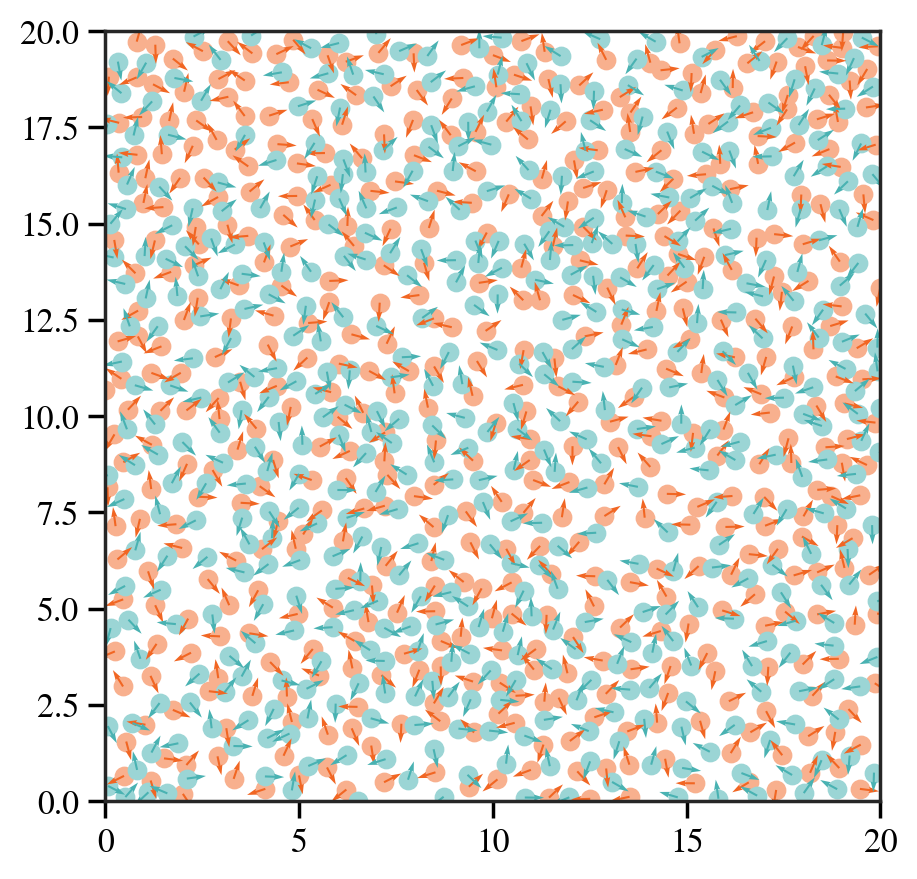

In [19]:
model.plot()

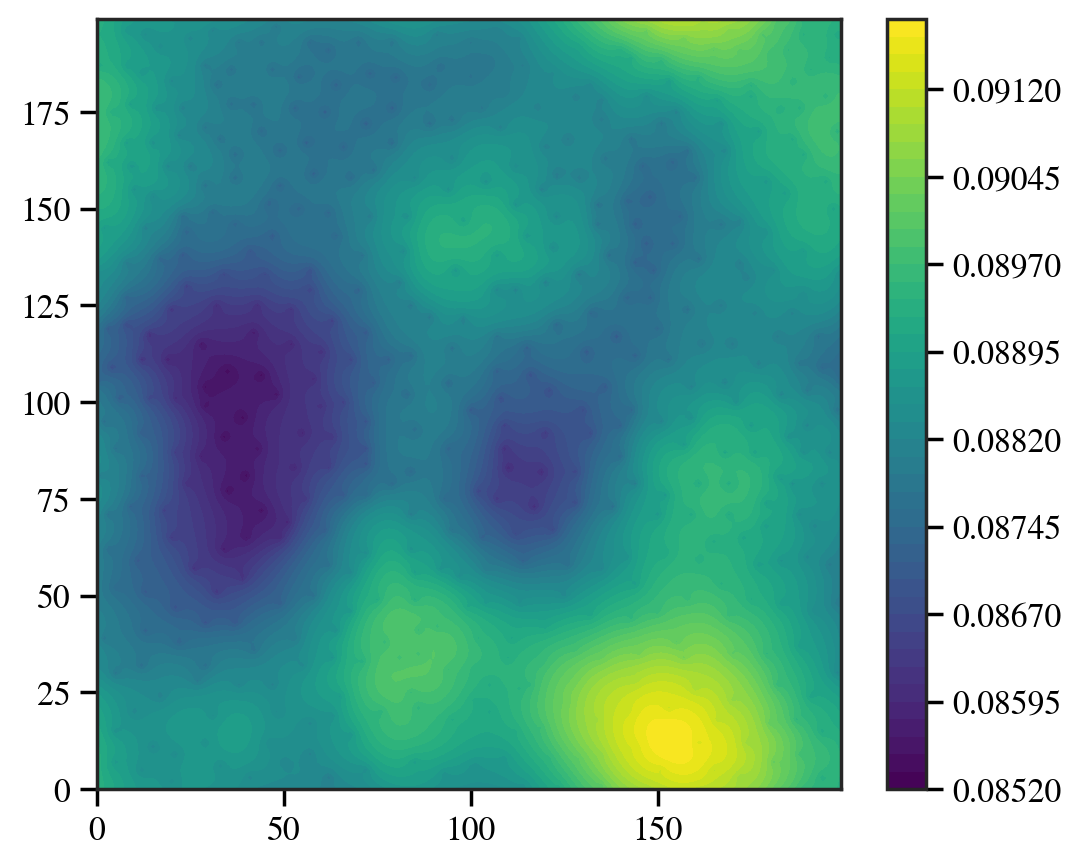

In [22]:
_, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(model.c1.T, cmap='viridis', levels=50)
plt.colorbar(cf)

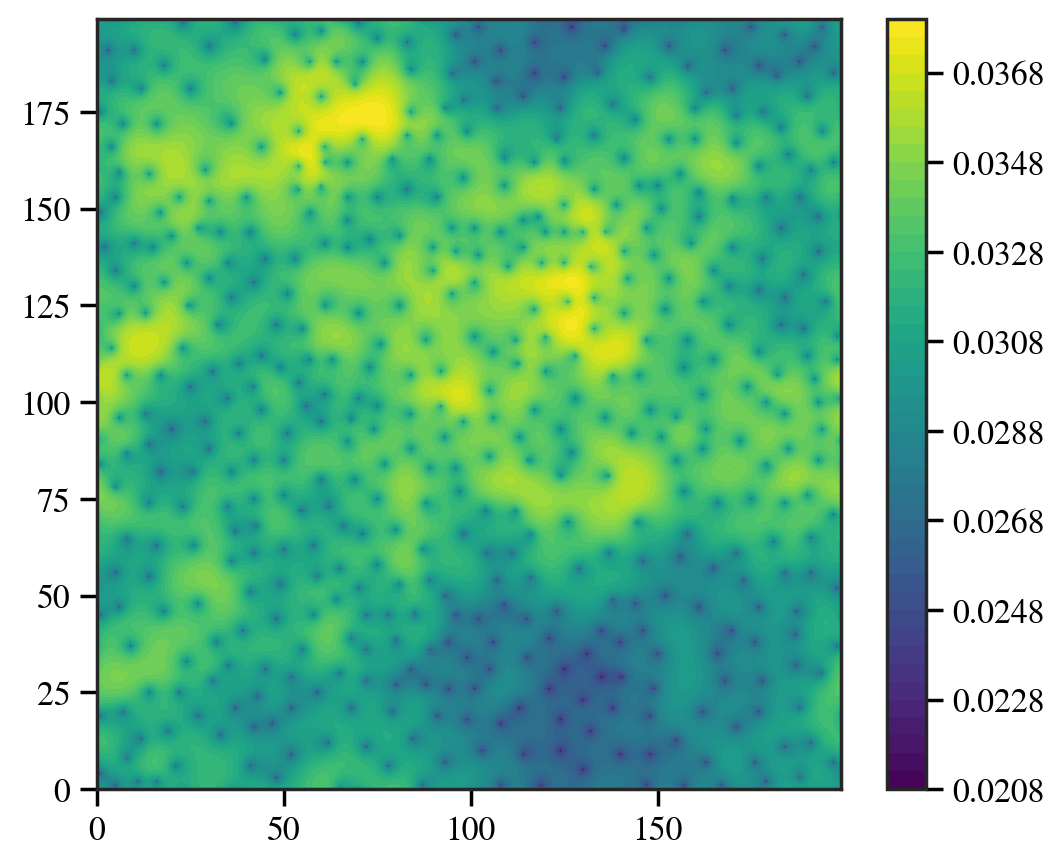

In [23]:
_, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(model.c2.T, cmap='viridis', levels=50)
plt.colorbar(cf)